# Análisis exploratorio: insatisfacción de clientes en Olist

Modelos y Simulación II, Universidad de Antioquia. Primer entregable, sección 2 de la guía del proyecto.

Queremos saber qué lleva a un cliente de Olist, un marketplace brasileño, a calificar mal su compra, y predecirlo antes de que lo haga. Partimos de la idea de que la insatisfacción afecta la fidelización y las ventas; en la sección 7 revisamos qué tanto de eso se ve en los datos.

Usamos el [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce): unas 100 000 órdenes entre 2016 y 2018, repartidas en 9 tablas.

## 0. Entorno y descarga de datos

`kagglehub` descarga el dataset público sin credenciales y lo deja en caché, así que la celda funciona igual en local y en Colab.

In [1]:
# En Colab, descomentar la siguiente línea
# !pip install -q kagglehub

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import kagglehub

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Colores: satisfecho (azul) e insatisfecho (naranja)
C_SAT, C_INS = "#2a78d6", "#eb6834"
C_GRIS = "#8a8984"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold",
})

# Figuras que van al informe (formato vectorial para LaTeX)
FIG_DIR = "informe/figuras"
os.makedirs(FIG_DIR, exist_ok=True)
def guardar(fig, nombre):
    fig.savefig(os.path.join(FIG_DIR, f"{nombre}.pdf"), bbox_inches="tight")

RUTA = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print(RUTA)
sorted(os.listdir(RUTA))

/home/alexizher/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2


['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

## 1. Composición de la base de datos

In [2]:
archivos = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "translation": "product_category_name_translation.csv",
}
df = {k: pd.read_csv(os.path.join(RUTA, v)) for k, v in archivos.items()}

resumen = pd.DataFrame({
    "filas": {k: len(v) for k, v in df.items()},
    "columnas": {k: v.shape[1] for k, v in df.items()},
    "celdas_faltantes": {k: int(v.isna().sum().sum()) for k, v in df.items()},
})
resumen

,filas,columnas,celdas_faltantes
customers,99441,5,0
geolocation,1000163,5,0
order_items,112650,7,0
payments,103886,5,0
reviews,99224,7,145903
orders,99441,8,4908
products,32951,9,2448
sellers,3095,4,0
translation,71,2,0


Las tablas se unen por llaves:

- `orders` es la tabla central (una fila por orden). Se une con `customers` por `customer_id`, con `reviews`, `order_items` y `payments` por `order_id`.
- `order_items` tiene una fila por artículo y apunta a `products` (`product_id`) y a `sellers` (`seller_id`).
- `geolocation` tiene coordenadas por prefijo de código postal, con muchas filas repetidas por prefijo.

`customer_id` cambia en cada orden; el identificador estable de la persona es `customer_unique_id`. Lo usamos para medir recompra.

In [3]:
for nombre in ["orders", "order_items", "payments", "reviews", "products", "customers", "sellers"]:
    print(f"--- {nombre}")
    display(df[nombre].head(3))

--- orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


--- order_items


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.900,13.290
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.900,19.930
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.000,17.870


--- payments


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.000,287.000,1.000,225.000,16.000,10.000,14.000
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.000,276.000,1.000,"1,000.000",30.000,18.000,20.000
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.000,250.000,1.000,154.000,18.000,9.000,15.000


--- customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


--- sellers


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


## 2. Datos faltantes

In [4]:
faltantes = []
for nombre, t in df.items():
    na = t.isna().sum()
    for col, n in na[na > 0].items():
        faltantes.append({"tabla": nombre, "columna": col, "faltantes": n, "porcentaje": 100 * n / len(t)})
faltantes = pd.DataFrame(faltantes).sort_values("porcentaje", ascending=False)
faltantes

,tabla,columna,faltantes,porcentaje
0,reviews,review_comment_title,87656,88.342
1,reviews,review_comment_message,58247,58.703
4,orders,order_delivered_customer_date,2965,2.982
6,products,product_name_lenght,610,1.851
5,products,product_category_name,610,1.851
7,products,product_description_lenght,610,1.851
8,products,product_photos_qty,610,1.851
3,orders,order_delivered_carrier_date,1783,1.793
2,orders,order_approved_at,160,0.161
9,products,product_weight_g,2,0.006


Lectura:

- Los títulos y mensajes de las reseñas faltan en la mayoría de los casos porque el comentario es opcional. Los dejamos fuera del modelo porque el cliente los escribe al mismo tiempo que la calificación, y filtrarían información de la etiqueta.
- En `orders`, las fechas de entrega faltan sobre todo en órdenes que no llegaron (canceladas, no disponibles, en tránsito). El faltante depende del estado de la orden.
- En `products`, 610 productos no tienen categoría ni datos de descripción, y 2 no tienen dimensiones.

In [5]:
o = df["orders"]
fechas = ["order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date"]
o[fechas].isna().groupby(o["order_status"]).mean().mul(100).round(1)

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0.000,100.000,100.000
canceled,22.600,88.000,99.000
created,100.000,100.000,100.000
delivered,0.000,0.000,0.000
invoiced,0.000,100.000,100.000
processing,0.000,100.000,100.000
shipped,0.000,0.000,100.000
unavailable,0.000,100.000,100.000


## 3. Variable objetivo: `review_score`

In [6]:
r = df["reviews"].copy()
print("reseñas:", len(r))
print("órdenes con más de una reseña:", r["order_id"].duplicated().sum())
print("review_id repetidos (una reseña para varias órdenes):", r["review_id"].duplicated().sum())
print("órdenes sin reseña:", (~o["order_id"].isin(r["order_id"])).sum())

reseñas: 99224
órdenes con más de una reseña: 551
review_id repetidos (una reseña para varias órdenes): 814


órdenes sin reseña: 768


Hay órdenes con varias reseñas. Nos quedamos con la más reciente de cada orden (por `review_answer_timestamp`), que es la calificación final del cliente.

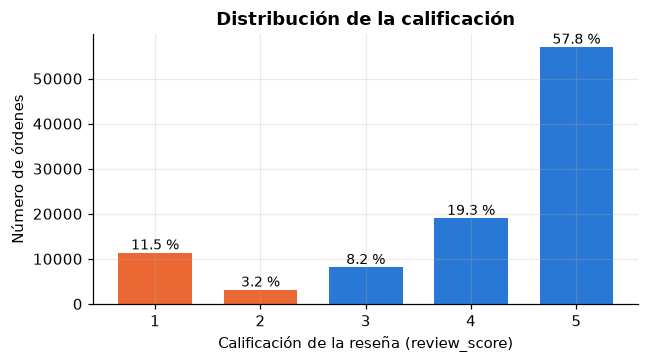

In [7]:
for c in ["review_creation_date", "review_answer_timestamp"]:
    r[c] = pd.to_datetime(r[c])
r = (r.sort_values("review_answer_timestamp")
       .drop_duplicates("order_id", keep="last")[["order_id", "review_score", "review_creation_date"]])

dist = r["review_score"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 3.4))
colores = [C_INS, C_INS, C_SAT, C_SAT, C_SAT]
ax.bar(dist.index.astype(str), dist.values, color=colores, width=0.7)
for x, v in zip(dist.index.astype(str), dist.values):
    ax.text(x, v, f"{100 * v / dist.sum():.1f} %", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Calificación de la reseña (review_score)")
ax.set_ylabel("Número de órdenes")
ax.set_title("Distribución de la calificación")
plt.tight_layout(); guardar(fig, "dist_review_score"); plt.show()

Definimos la variable objetivo como binaria:

$$y = \begin{cases} 1 & \text{(insatisfecho)} \quad \text{si } \texttt{review\_score} \in \{1, 2\} \\ 0 & \text{(satisfecho)} \quad \text{si } \texttt{review\_score} \in \{3, 4, 5\} \end{cases}$$

Es el mismo corte que usan Wong y Marikannan (2020), Zaghloul et al. (2024) y Orman (2026), lo que permite comparar resultados. La calificación 3 queda del lado satisfecho; en la etapa de modelado podemos probar la variante 1-3 contra 4-5 como análisis de sensibilidad.

In [8]:
r["insatisfecho"] = (r["review_score"] <= 2).astype(int)
r["insatisfecho"].value_counts(normalize=True).rename({0: "satisfecho", 1: "insatisfecho"})

insatisfecho
satisfecho     0.853
insatisfecho   0.147
Name: proportion, dtype: float64

## 4. Tabla a nivel de orden

Cada fila del dataset final es una orden con su reseña. Calculamos las variables con la información disponible al momento de la entrega, sin tocar nada de la reseña.

Primero revisamos cómo cambia la insatisfacción según el estado de la orden:

In [9]:
tmp = o.merge(r, on="order_id", how="inner")
por_estado = tmp.groupby("order_status")["insatisfecho"].agg(["size", "mean"]).sort_values("size", ascending=False)
por_estado.columns = ["ordenes", "tasa_insatisfaccion"]
por_estado

,ordenes,tasa_insatisfaccion
order_status,,
delivered,95832,0.128
shipped,1032,0.696
canceled,605,0.769
unavailable,595,0.849
invoiced,309,0.828
processing,295,0.929
created,3,0.667
approved,2,0.500


Las órdenes no entregadas (canceladas, no disponibles, enviadas sin llegar) tienen entre 70 % y 93 % de insatisfacción, pero son pocas y no tienen fecha de entrega. Restringimos el análisis a órdenes con estado `delivered` y fecha de entrega registrada. Así las variables de entrega están definidas para todas las filas y el problema queda como: *dado que la orden llegó, ¿qué la lleva a una mala calificación?*

In [10]:
fechas_o = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
            "order_delivered_customer_date", "order_estimated_delivery_date"]
o = df["orders"].copy()
for c in fechas_o:
    o[c] = pd.to_datetime(o[c])

o = o[(o["order_status"] == "delivered") & o["order_delivered_customer_date"].notna()]
o = o.merge(r, on="order_id", how="inner")
o = o.merge(df["customers"], on="customer_id", how="left")
print(o.shape)

(95824, 15)


### 4.1 Artículos, productos y vendedores

In [11]:
prod = df["products"].merge(df["translation"], on="product_category_name", how="left")
prod["categoria"] = prod["product_category_name_english"].fillna(prod["product_category_name"])
prod["volumen_cm3"] = prod["product_length_cm"] * prod["product_height_cm"] * prod["product_width_cm"]

it = (df["order_items"]
      .merge(prod[["product_id", "categoria", "product_weight_g", "volumen_cm3", "product_photos_qty",
                   "product_description_lenght", "product_name_lenght"]], on="product_id", how="left")
      .merge(df["sellers"][["seller_id", "seller_state", "seller_zip_code_prefix"]], on="seller_id", how="left"))
it["shipping_limit_date"] = pd.to_datetime(it["shipping_limit_date"])

agg_items = it.groupby("order_id").agg(
    n_articulos=("order_item_id", "size"),
    n_productos=("product_id", "nunique"),
    n_vendedores=("seller_id", "nunique"),
    precio_total=("price", "sum"),
    flete_total=("freight_value", "sum"),
    peso_total_g=("product_weight_g", "sum"),
    volumen_total_cm3=("volumen_cm3", "sum"),
    fotos_promedio=("product_photos_qty", "mean"),
    largo_descripcion=("product_description_lenght", "mean"),
    largo_nombre=("product_name_lenght", "mean"),
    limite_envio=("shipping_limit_date", "max"),
)
# Categoría y estado del vendedor del artículo más caro de la orden
principal = (it.sort_values("price", ascending=False).drop_duplicates("order_id")
               .set_index("order_id")[["categoria", "seller_state", "seller_zip_code_prefix"]])
agg_items = agg_items.join(principal)
agg_items.head()

,n_articulos,n_productos,n_vendedores,precio_total,flete_total,peso_total_g,volumen_total_cm3,fotos_promedio,largo_descripcion,largo_nombre,limite_envio,categoria,seller_state,seller_zip_code_prefix
order_id,,,,,,,,,,,,,,
00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.900,13.290,650.000,"3,528.000",4.000,598.000,58.000,2017-09-19 09:45:35,cool_stuff,SP,27277
00018f77f2f0320c557190d7a144bdd3,1,1,1,239.900,19.930,"30,000.000","60,000.000",2.000,239.000,56.000,2017-05-03 11:05:13,pet_shop,SP,3471
000229ec398224ef6ca0657da4fc703e,1,1,1,199.000,17.870,"3,050.000","14,157.000",2.000,695.000,59.000,2018-01-18 14:48:30,furniture_decor,MG,37564
00024acbcdf0a6daa1e931b038114c75,1,1,1,12.990,12.790,200.000,"2,400.000",1.000,480.000,42.000,2018-08-15 10:10:18,perfumery,SP,14403
00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.900,18.140,"3,750.000","42,000.000",1.000,409.000,59.000,2017-02-13 13:57:51,garden_tools,PR,87900


### 4.2 Pagos

In [12]:
pay = df["payments"]
agg_pay = pay.groupby("order_id").agg(
    valor_pagado=("payment_value", "sum"),
    cuotas=("payment_installments", "max"),
    n_medios_pago=("payment_sequential", "max"),
)
agg_pay["tipo_pago"] = (pay.sort_values("payment_value", ascending=False)
                          .drop_duplicates("order_id").set_index("order_id")["payment_type"])
agg_pay["tipo_pago"].value_counts()

tipo_pago
credit_card    74975
boleto         19784
voucher         3151
debit_card      1527
not_defined        3
Name: count, dtype: int64

### 4.3 Distancia entre cliente y vendedor

`geolocation` tiene varias coordenadas por prefijo postal. Tomamos la mediana por prefijo y calculamos la distancia haversine entre el cliente y el vendedor principal:

$$d = 2R \arcsin\sqrt{\sin^2\!\left(\tfrac{\Delta\varphi}{2}\right) + \cos\varphi_1 \cos\varphi_2 \sin^2\!\left(\tfrac{\Delta\lambda}{2}\right)}, \qquad R = 6371 \text{ km}$$

In [13]:
geo = (df["geolocation"].groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]]
       .median())

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

### 4.4 Unión y variables derivadas

Variables de tiempo, en días:

| Variable | Definición |
|---|---|
| `dias_aprobacion` | aprobación del pago menos compra |
| `dias_a_transportadora` | entrega a la transportadora menos aprobación |
| `dias_entrega` | entrega al cliente menos compra |
| `dias_estimados` | fecha estimada de entrega menos compra (lo que Olist prometió) |
| `retraso_dias` | entrega real menos entrega estimada (positivo = tarde) |
| `entrega_tarde` | 1 si `retraso_dias` > 0 |
| `vendedor_tarde` | 1 si el vendedor entregó a la transportadora después del límite de envío |

In [14]:
D = o.set_index("order_id").join(agg_items).join(agg_pay)

dias = lambda a, b: (D[a] - D[b]).dt.total_seconds() / 86400
D["dias_aprobacion"] = dias("order_approved_at", "order_purchase_timestamp")
D["dias_a_transportadora"] = dias("order_delivered_carrier_date", "order_approved_at")
D["dias_entrega"] = dias("order_delivered_customer_date", "order_purchase_timestamp")
D["dias_estimados"] = dias("order_estimated_delivery_date", "order_purchase_timestamp")
D["retraso_dias"] = dias("order_delivered_customer_date", "order_estimated_delivery_date")
D["entrega_tarde"] = (D["retraso_dias"] > 0).astype(int)
D["vendedor_tarde"] = (D["order_delivered_carrier_date"] > D["limite_envio"]).astype(int)

D["flete_relativo"] = D["flete_total"] / D["precio_total"]
D["mismo_estado"] = (D["customer_state"] == D["seller_state"]).astype(int)
D["mes_compra"] = D["order_purchase_timestamp"].dt.month
D["dia_semana_compra"] = D["order_purchase_timestamp"].dt.dayofweek
D["hora_compra"] = D["order_purchase_timestamp"].dt.hour

c_geo = geo.reindex(D["customer_zip_code_prefix"]).to_numpy()
s_geo = geo.reindex(D["seller_zip_code_prefix"]).to_numpy()
D["distancia_km"] = haversine_km(c_geo[:, 0], c_geo[:, 1], s_geo[:, 0], s_geo[:, 1])

print(D.shape)

(95824, 45)


In [15]:
NUM = ["n_articulos", "n_productos", "n_vendedores", "precio_total", "flete_total", "flete_relativo",
       "valor_pagado", "cuotas", "n_medios_pago", "peso_total_g", "volumen_total_cm3", "fotos_promedio",
       "largo_descripcion", "largo_nombre", "dias_aprobacion", "dias_a_transportadora", "dias_entrega",
       "dias_estimados", "retraso_dias", "distancia_km", "mes_compra", "dia_semana_compra", "hora_compra"]
BIN = ["entrega_tarde", "vendedor_tarde", "mismo_estado"]
CAT = ["tipo_pago", "categoria", "customer_state", "seller_state"]
OBJ = "insatisfecho"

datos = D[NUM + BIN + CAT + [OBJ, "review_score", "customer_unique_id", "order_purchase_timestamp"]].copy()
print(f"muestras: {len(datos):,}")
print(f"variables de entrada: {len(NUM + BIN + CAT)} ({len(NUM)} numéricas, {len(BIN)} binarias, {len(CAT)} categóricas)")
print(f"tasa de insatisfacción: {datos[OBJ].mean():.2%}")

muestras: 95,824
variables de entrada: 30 (23 numéricas, 3 binarias, 4 categóricas)
tasa de insatisfacción: 12.81%


In [16]:
desc = pd.DataFrame({
    "tipo": ["numérica"] * len(NUM) + ["binaria"] * len(BIN) + ["categórica"] * len(CAT),
    "faltantes": datos[NUM + BIN + CAT].isna().sum().values,
    "valores_distintos": datos[NUM + BIN + CAT].nunique().values,
}, index=NUM + BIN + CAT)
desc["pct_faltantes"] = 100 * desc["faltantes"] / len(datos)
desc

,tipo,faltantes,valores_distintos,pct_faltantes
n_articulos,numérica,0,17,0.000
n_productos,numérica,0,8,0.000
n_vendedores,numérica,0,5,0.000
precio_total,numérica,0,7603,0.000
flete_total,numérica,0,7845,0.000
flete_relativo,numérica,0,43356,0.000
valor_pagado,numérica,1,27355,0.001
cuotas,numérica,1,24,0.001
n_medios_pago,numérica,1,19,0.001
peso_total_g,numérica,0,2851,0.000


In [17]:
datos[NUM].describe(percentiles=[0.01, 0.5, 0.99]).T

,count,mean,std,min,1%,50%,99%,max
n_articulos,"95,824.000",1.141,0.534,1.000,1.000,1.000,3.000,21.000
n_productos,"95,824.000",1.038,0.227,1.000,1.000,1.000,2.000,8.000
n_vendedores,"95,824.000",1.014,0.123,1.000,1.000,1.000,2.000,5.000
precio_total,"95,824.000",136.800,207.788,0.850,11.990,86.250,990.000,"13,440.000"
flete_total,"95,824.000",22.763,21.523,0.000,7.390,17.160,104.113,"1,794.960"
flete_relativo,"95,824.000",0.308,0.312,0.000,0.025,0.224,1.456,21.447
valor_pagado,"95,823.000",159.593,217.513,9.590,22.380,105.280,"1,048.513","13,664.080"
cuotas,"95,823.000",2.926,2.710,0.000,1.000,2.000,10.000,24.000
n_medios_pago,"95,823.000",1.045,0.371,1.000,1.000,1.000,2.000,26.000
peso_total_g,"95,824.000","2,382.422","4,765.754",0.000,90.230,750.000,"22,350.000","184,400.000"


Hay 1343 órdenes (1,4 %) con `dias_a_transportadora` negativo: la fecha de entrega a la transportadora es anterior a la aprobación del pago, lo que indica errores de registro. En el preprocesamiento del modelo los recortamos a cero.

In [18]:
print("dias_a_transportadora < 0:", (datos["dias_a_transportadora"] < 0).sum())
print("dias_aprobacion < 0:", (datos["dias_aprobacion"] < 0).sum())

dias_a_transportadora < 0: 1343
dias_aprobacion < 0: 0


## 5. Análisis univariado

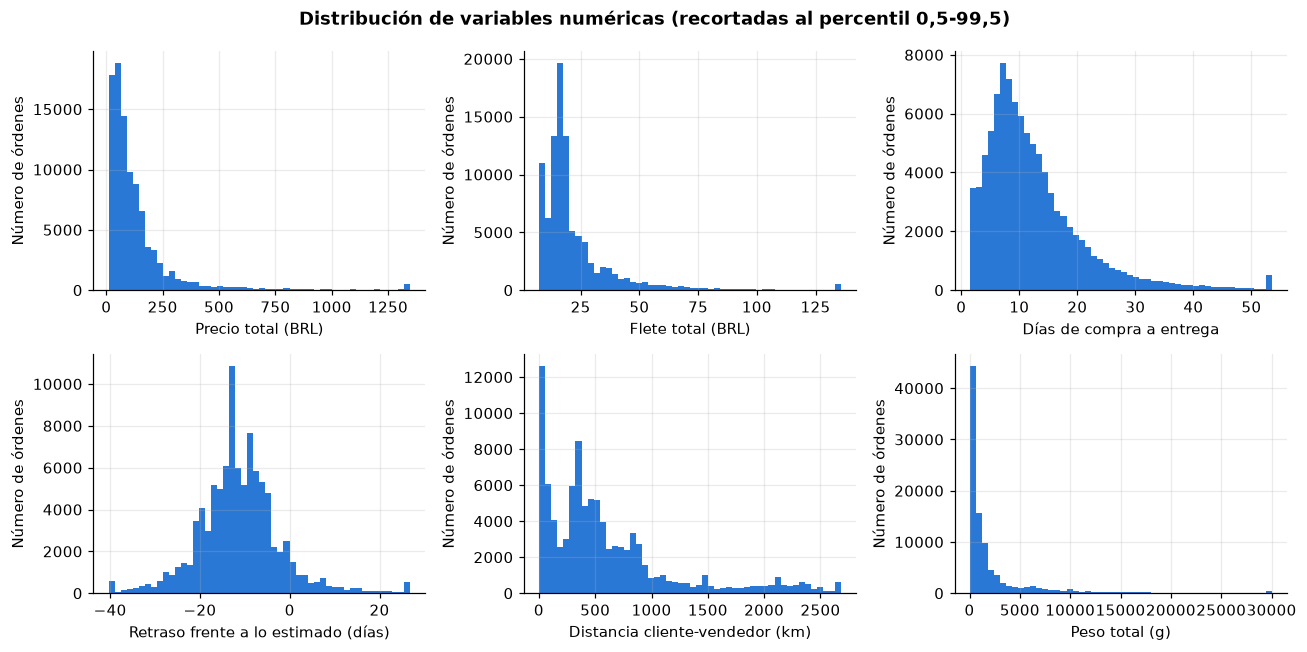

In [19]:
vars_hist = ["precio_total", "flete_total", "dias_entrega", "retraso_dias", "distancia_km", "peso_total_g"]
etiquetas = {
    "precio_total": "Precio total (BRL)", "flete_total": "Flete total (BRL)",
    "dias_entrega": "Días de compra a entrega", "retraso_dias": "Retraso frente a lo estimado (días)",
    "distancia_km": "Distancia cliente-vendedor (km)", "peso_total_g": "Peso total (g)",
}
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, v in zip(axes.ravel(), vars_hist):
    x = datos[v].dropna()
    x = x.clip(x.quantile(0.005), x.quantile(0.995))
    ax.hist(x, bins=50, color=C_SAT)
    ax.set_xlabel(etiquetas[v]); ax.set_ylabel("Número de órdenes")
fig.suptitle("Distribución de variables numéricas (recortadas al percentil 0,5-99,5)", fontweight="bold")
plt.tight_layout(); plt.show()

Precio, flete, peso y distancia tienen colas largas a la derecha. Para modelos sensibles a la escala (regresión logística, SVM, redes, KNN) conviene aplicar logaritmo antes de estandarizar.

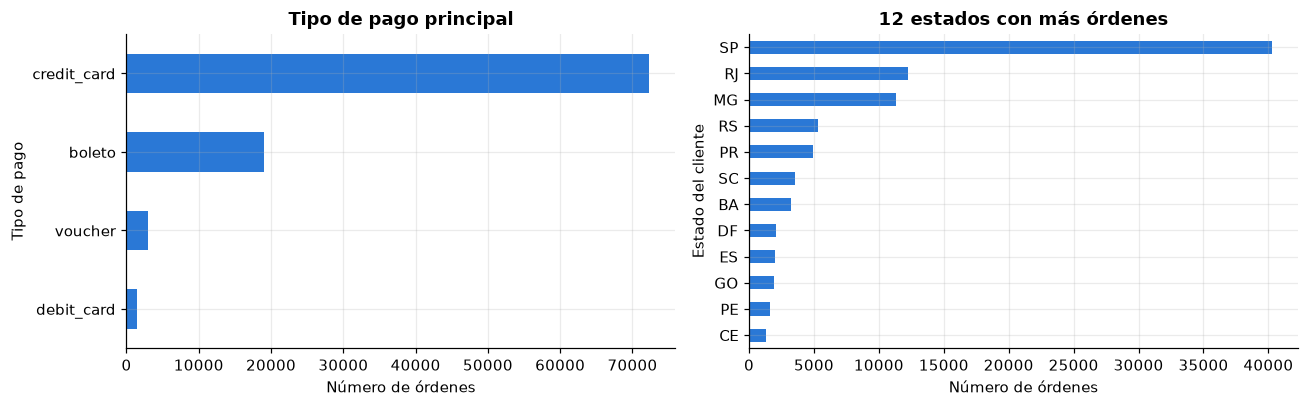

categorías de producto distintas: 73


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
datos["tipo_pago"].value_counts().plot.barh(ax=axes[0], color=C_SAT)
axes[0].set_xlabel("Número de órdenes"); axes[0].set_ylabel("Tipo de pago"); axes[0].invert_yaxis()
datos["customer_state"].value_counts().head(12).plot.barh(ax=axes[1], color=C_SAT)
axes[1].set_xlabel("Número de órdenes"); axes[1].set_ylabel("Estado del cliente"); axes[1].invert_yaxis()
axes[0].set_title("Tipo de pago principal"); axes[1].set_title("12 estados con más órdenes")
plt.tight_layout(); plt.show()
print("categorías de producto distintas:", datos["categoria"].nunique())

## 6. Análisis bivariado contra la insatisfacción

### 6.1 Entrega

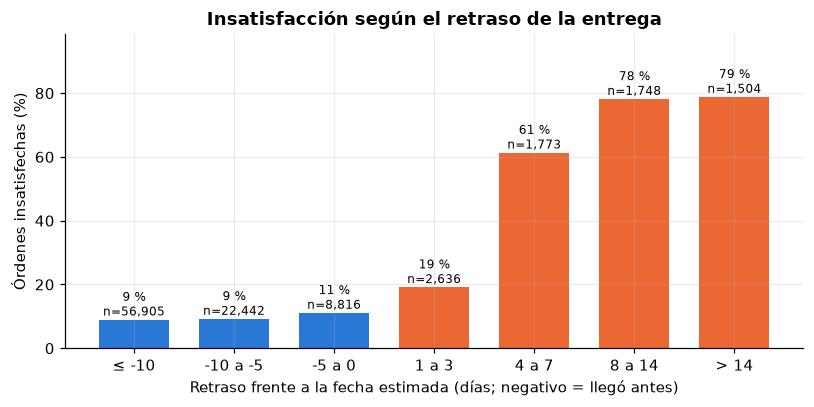

,mean,size
tramo_retraso,,
≤ -10,0.090,56905
-10 a -5,0.092,22442
-5 a 0,0.111,8816
1 a 3,0.191,2636
4 a 7,0.613,1773
8 a 14,0.781,1748
> 14,0.788,1504


In [21]:
bins = [-np.inf, -10, -5, 0, 3, 7, 14, np.inf]
nombres = ["≤ -10", "-10 a -5", "-5 a 0", "1 a 3", "4 a 7", "8 a 14", "> 14"]
datos["tramo_retraso"] = pd.cut(datos["retraso_dias"], bins=bins, labels=nombres)
t = datos.groupby("tramo_retraso", observed=True)[OBJ].agg(["mean", "size"])

fig, ax = plt.subplots(figsize=(7.5, 3.8))
col = [C_SAT if i < 3 else C_INS for i in range(len(t))]
ax.bar(t.index.astype(str), 100 * t["mean"], color=col, width=0.7)
for x, (m, n) in zip(t.index.astype(str), t.values):
    ax.text(x, 100 * m, f"{100 * m:.0f} %\nn={int(n):,}", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Retraso frente a la fecha estimada (días; negativo = llegó antes)")
ax.set_ylabel("Órdenes insatisfechas (%)")
ax.set_title("Insatisfacción según el retraso de la entrega")
ax.set_ylim(0, 100 * t["mean"].max() * 1.25)
plt.tight_layout(); guardar(fig, "insatisfaccion_retraso"); plt.show()
t

In [22]:
resumen_bin = []
for v in BIN:
    g = datos.groupby(v)[OBJ].agg(["mean", "size"])
    resumen_bin.append({"variable": v, "tasa_si_0": g.loc[0, "mean"], "tasa_si_1": g.loc[1, "mean"],
                        "n_1": int(g.loc[1, "size"]), "pct_1": g.loc[1, "size"] / len(datos)})
pd.DataFrame(resumen_bin).set_index("variable")

,tasa_si_0,tasa_si_1,n_1,pct_1
variable,,,,
entrega_tarde,0.092,0.541,7661,0.080
vendedor_tarde,0.117,0.238,8609,0.090
mismo_estado,0.141,0.105,34481,0.360


Lectura:

- Mientras la orden llegue antes o en la fecha estimada, la insatisfacción se queda entre 9 % y 11 %. Con 1 a 3 días de retraso sube a 19 %, y de 4 días en adelante pasa del 60 %. Nos sorprendió lo brusco del salto.
- Que el vendedor despache tarde a la transportadora también sube la tasa, pero menos que el retraso final: parte del retraso viene de la logística.

### 6.2 Tamaño de la orden y número de vendedores

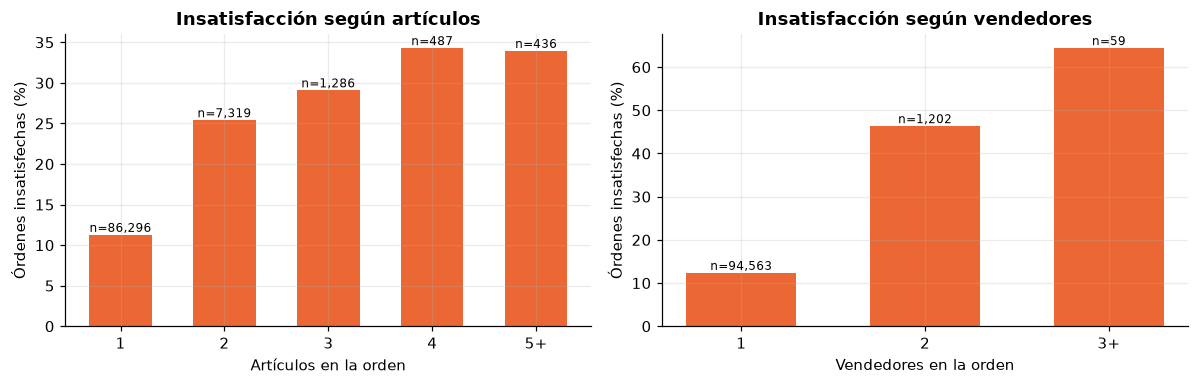

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, v, xl in [(axes[0], "n_articulos", "Artículos en la orden"), (axes[1], "n_vendedores", "Vendedores en la orden")]:
    x = datos[v].clip(upper=5 if v == "n_articulos" else 3)
    g = datos.groupby(x)[OBJ].agg(["mean", "size"])
    etq = [str(int(i)) if i < x.max() else f"{int(i)}+" for i in g.index]
    ax.bar(etq, 100 * g["mean"], color=C_INS, width=0.6)
    for e, (m, n) in zip(etq, g.values):
        ax.text(e, 100 * m, f"n={int(n):,}", ha="center", va="bottom", fontsize=8)
    ax.set_xlabel(xl); ax.set_ylabel("Órdenes insatisfechas (%)")
axes[0].set_title("Insatisfacción según artículos"); axes[1].set_title("Insatisfacción según vendedores")
plt.tight_layout(); plt.show()

La insatisfacción pasa de 11 % con un artículo a 25 % con dos. Con dos vendedores sube a 46 %, aunque esas órdenes son pocas (1202). Una hipótesis: llegan en envíos separados y el cliente califica cuando recibe solo una parte.

### 6.3 Variables numéricas: satisfechos contra insatisfechos

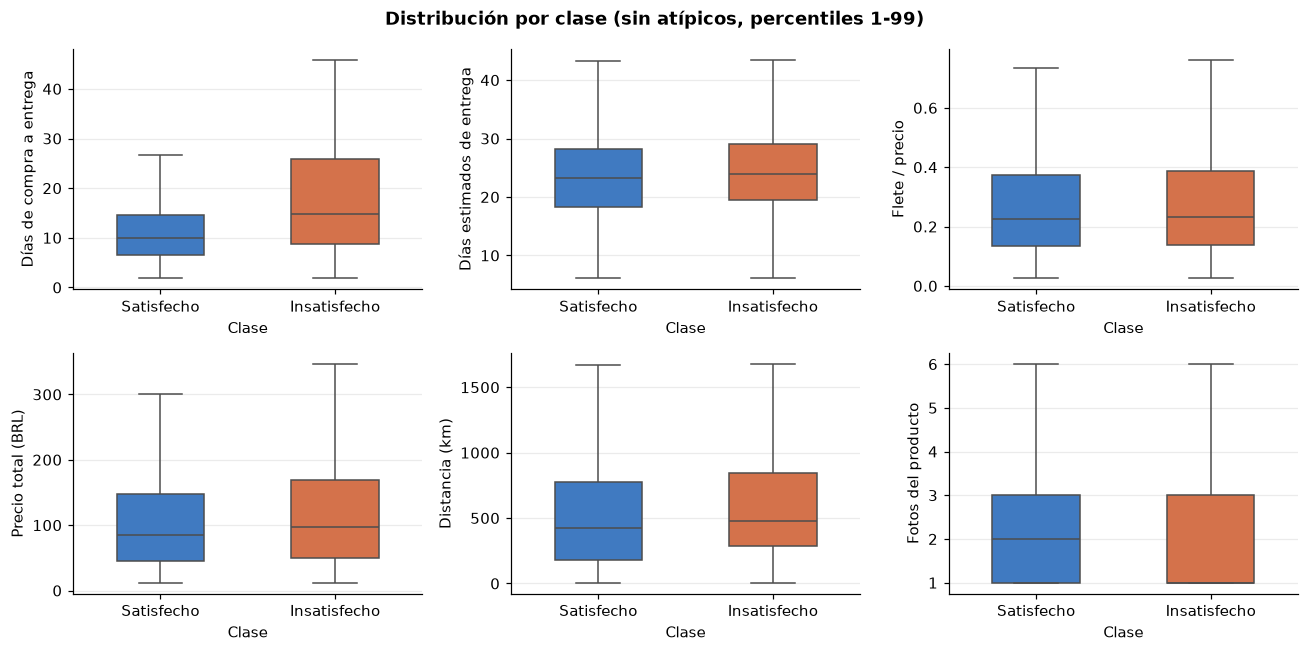

In [24]:
vars_box = ["dias_entrega", "dias_estimados", "flete_relativo", "precio_total", "distancia_km", "fotos_promedio"]
etq_box = {"dias_entrega": "Días de compra a entrega", "dias_estimados": "Días estimados de entrega",
           "flete_relativo": "Flete / precio", "precio_total": "Precio total (BRL)",
           "distancia_km": "Distancia (km)", "fotos_promedio": "Fotos del producto"}
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, v in zip(axes.ravel(), vars_box):
    s = datos[[v, OBJ]].dropna()
    s = s[s[v].between(s[v].quantile(0.01), s[v].quantile(0.99))]
    sns.boxplot(data=s, x=OBJ, y=v, hue=OBJ, ax=ax, palette=[C_SAT, C_INS], legend=False,
                showfliers=False, width=0.5)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Satisfecho", "Insatisfecho"])
    ax.set_xlabel("Clase"); ax.set_ylabel(etq_box[v])
fig.suptitle("Distribución por clase (sin atípicos, percentiles 1-99)", fontweight="bold")
plt.tight_layout(); plt.show()

### 6.4 Capacidad discriminante individual

Para cada variable numérica calculamos:

- La correlación de Spearman $\rho_s$ con la etiqueta binaria (captura relaciones monótonas y no depende de la escala).
- El AUC univariado: la probabilidad de que una orden insatisfecha tenga un valor mayor de la variable que una satisfecha. Es equivalente al estadístico U de Mann-Whitney normalizado, $\text{AUC} = U / (n_0 n_1)$. Un valor de 0,5 indica que la variable no discrimina; reportamos $\max(\text{AUC}, 1-\text{AUC})$.

Retomamos este análisis en la sección 5.1 de la guía (análisis individual de variables).

In [25]:
filas = []
y = datos[OBJ]
for v in NUM + BIN:
    s = datos[[v, OBJ]].dropna()
    rho, p = stats.spearmanr(s[v], s[OBJ])
    u = stats.mannwhitneyu(s.loc[s[OBJ] == 1, v], s.loc[s[OBJ] == 0, v]).statistic
    auc = u / ((s[OBJ] == 1).sum() * (s[OBJ] == 0).sum())
    filas.append({"variable": v, "spearman": rho, "p_valor": p, "auc": max(auc, 1 - auc)})
disc = pd.DataFrame(filas).set_index("variable").sort_values("auc", ascending=False)
disc

,spearman,p_valor,auc
variable,,,
dias_entrega,0.215,0.000,0.685
retraso_dias,0.182,0.000,0.657
entrega_tarde,0.364,0.000,0.648
dias_a_transportadora,0.096,0.000,0.583
flete_total,0.094,0.000,0.581
n_articulos,0.140,0.000,0.563
valor_pagado,0.060,0.000,0.552
vendedor_tarde,0.103,0.000,0.544
precio_total,0.050,0.000,0.543


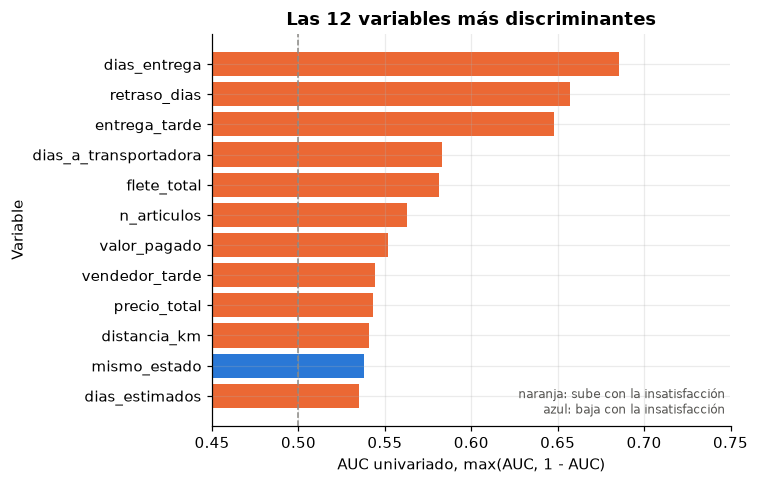

In [26]:
top = disc.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(top.index, top["auc"], color=[C_INS if r > 0 else C_SAT for r in top["spearman"]])
ax.axvline(0.5, color=C_GRIS, lw=1, ls="--")
ax.set_xlim(0.45, max(0.75, top["auc"].max() + 0.03))
ax.set_xlabel("AUC univariado, max(AUC, 1 - AUC)")
ax.set_ylabel("Variable")
ax.set_title("Las 12 variables más discriminantes")
ax.text(0.99, 0.02, "naranja: sube con la insatisfacción\nazul: baja con la insatisfacción",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color="#52514e")
plt.tight_layout(); guardar(fig, "auc_univariado"); plt.show()

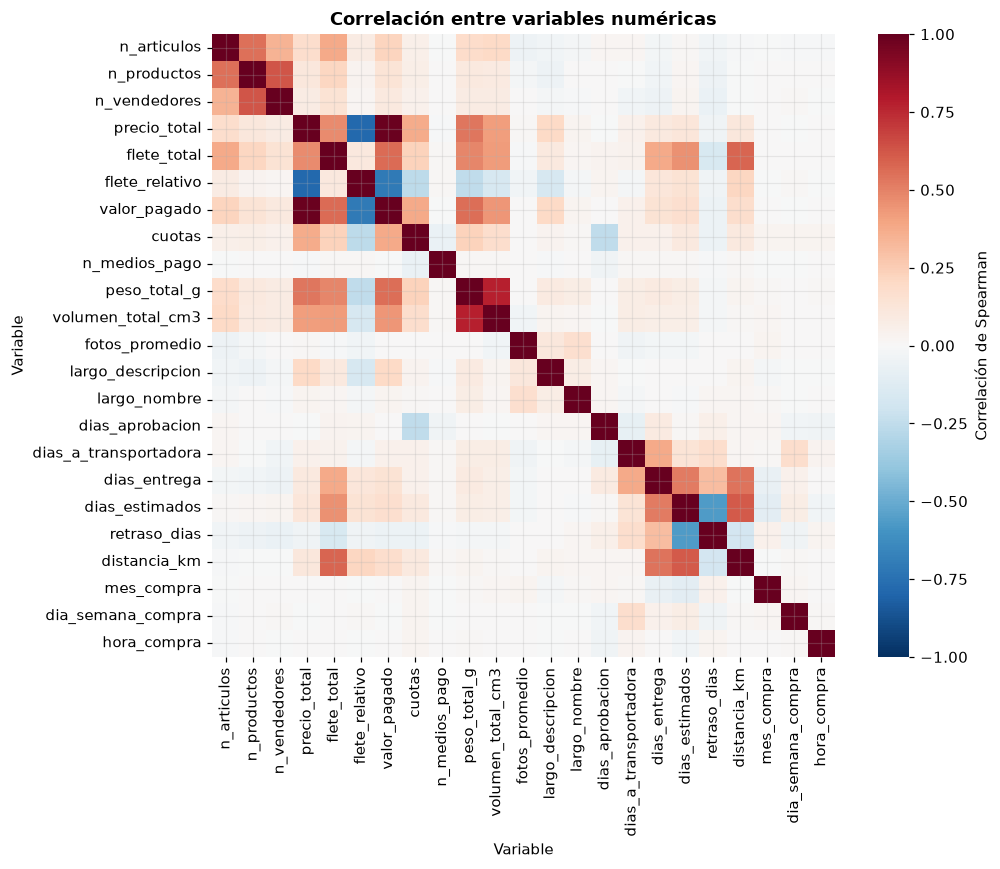

,level_0,level_1,rho
75,precio_total,valor_pagado,0.990


In [27]:
corr = datos[NUM].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"label": "Correlación de Spearman"})
ax.set_title("Correlación entre variables numéricas")
ax.set_xlabel("Variable"); ax.set_ylabel("Variable")
plt.tight_layout(); plt.show()

pares = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
             .rename("rho").reset_index().query("abs(rho) > 0.8"))
pares

Solo un par supera $|\rho| > 0{,}8$: precio total y valor pagado ($\rho = 0{,}99$), que miden casi lo mismo. Una de las dos sobra y es candidata a eliminarse en la etapa de reducción de dimensión.

### 6.5 Variables categóricas

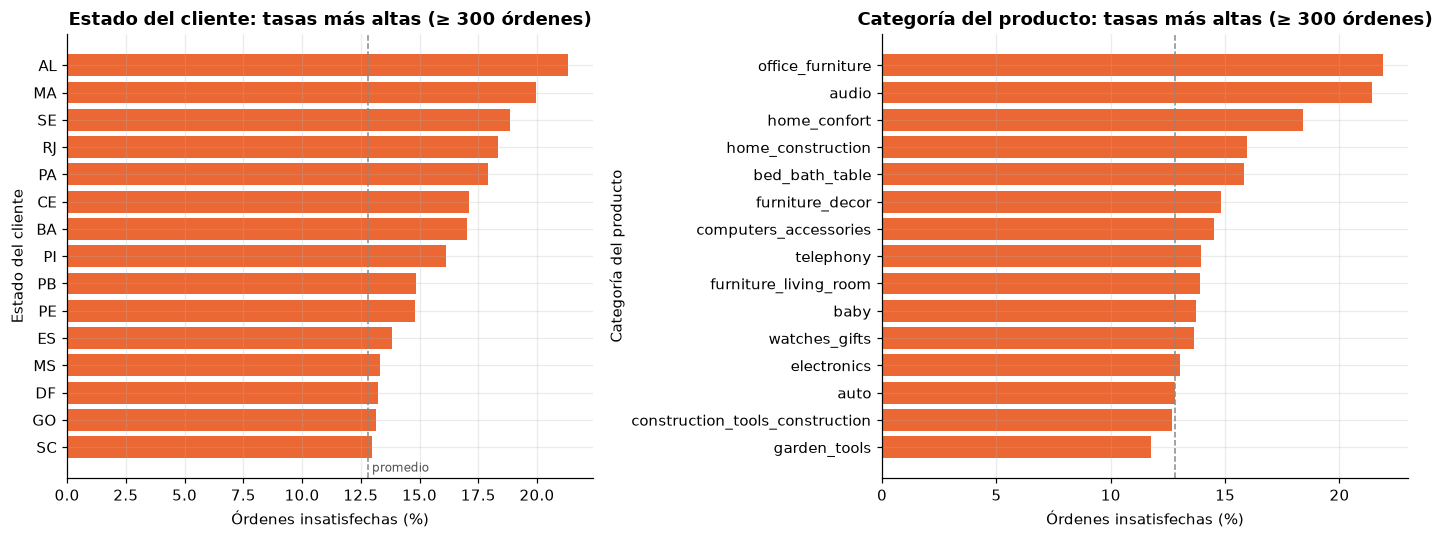

In [28]:
def tasa_por(col, minimo=300, top=15):
    g = datos.groupby(col)[OBJ].agg(["mean", "size"]).query("size >= @minimo")
    return g.sort_values("mean", ascending=False).head(top)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tasa_global = datos[OBJ].mean() * 100
for ax, col, tit in [(axes[0], "customer_state", "Estado del cliente"), (axes[1], "categoria", "Categoría del producto")]:
    g = tasa_por(col).iloc[::-1]
    ax.barh(g.index, 100 * g["mean"], color=C_INS)
    ax.axvline(tasa_global, color=C_GRIS, lw=1, ls="--")
    ax.set_xlabel("Órdenes insatisfechas (%)"); ax.set_ylabel(tit)
    ax.set_title(f"{tit}: tasas más altas (≥ 300 órdenes)")
axes[0].text(tasa_global, -0.9, " promedio", color="#52514e", fontsize=8)
plt.tight_layout(); plt.show()

In [29]:
datos.groupby("tipo_pago")[OBJ].agg(["mean", "size"])

,mean,size
tipo_pago,,
boleto,0.125,19062
credit_card,0.129,72331
debit_card,0.111,1477
voucher,0.135,2953


In [30]:
from scipy.stats import chi2_contingency

def cramers_v(a, b):
    tabla = pd.crosstab(a, b)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.to_numpy().sum()
    return np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))

pd.Series({c: cramers_v(datos[c].fillna("desconocido"), datos[OBJ]) for c in CAT}, name="V de Cramér")

tipo_pago        0.012
categoria        0.071
customer_state   0.086
seller_state     0.036
Name: V de Cramér, dtype: float64

La V de Cramér mide la asociación entre dos variables categóricas, de 0 (independientes) a 1:

$$V = \sqrt{\frac{\chi^2}{n \,(\min(r, c) - 1)}}$$

Estado, categoría y tipo de pago aportan poco por sí solos (V < 0,09), comparados con las variables de entrega.

### 6.6 Evolución en el tiempo

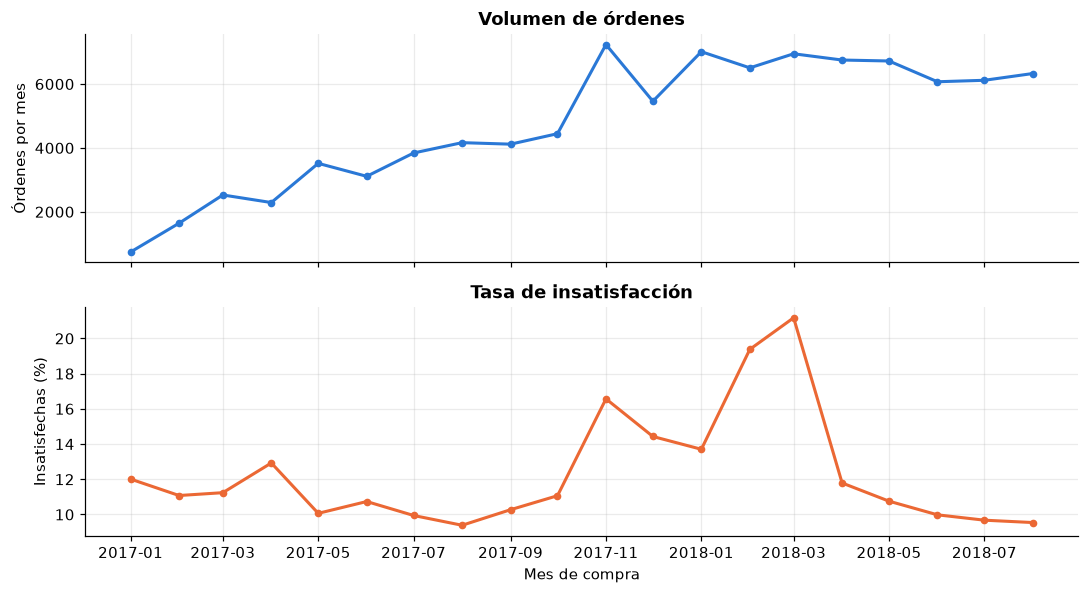

In [31]:
m = datos.set_index("order_purchase_timestamp").resample("MS").agg({OBJ: ["mean", "size"]})
m.columns = ["tasa", "ordenes"]
m = m[m["ordenes"] >= 500]

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
axes[0].plot(m.index, m["ordenes"], color=C_SAT, lw=2, marker="o", ms=4)
axes[0].set_ylabel("Órdenes por mes"); axes[0].set_title("Volumen de órdenes")
axes[1].plot(m.index, 100 * m["tasa"], color=C_INS, lw=2, marker="o", ms=4)
axes[1].set_ylabel("Insatisfechas (%)"); axes[1].set_title("Tasa de insatisfacción")
axes[1].set_xlabel("Mes de compra")
plt.tight_layout(); guardar(fig, "evolucion_mensual"); plt.show()

La tasa ronda el 10-12 % casi todo el periodo, con dos picos: noviembre de 2017 (16,6 %, el mes de Black Friday y el de mayor volumen) y febrero-marzo de 2018 (19,4 % y 21,2 %). Son meses de mucho volumen, lo que apunta a congestión logística y más retrasos. Como la tasa cambia en el tiempo, en la etapa de modelado conviene comparar una partición aleatoria estratificada con una partición temporal (entrenar con meses anteriores y evaluar con los últimos).

## 7. Insatisfacción y recompra

Revisamos si los clientes insatisfechos en su primera compra vuelven a comprar menos. Tomamos la primera orden de cada cliente (`customer_unique_id`) y marcamos si hizo otra compra después.

In [32]:
ords = datos.sort_values("order_purchase_timestamp")
primera = ords.drop_duplicates("customer_unique_id", keep="first").copy()
n_ordenes = ords.groupby("customer_unique_id").size()
primera["volvio"] = (primera["customer_unique_id"].map(n_ordenes) > 1).astype(int)

rec = primera.groupby(OBJ)["volvio"].agg(["mean", "size"]).rename(index={0: "satisfecho", 1: "insatisfecho"})
rec.columns = ["tasa_recompra", "clientes"]
print(f"clientes únicos: {len(primera):,}  |  recompra global: {primera['volvio'].mean():.2%}")
tabla = pd.crosstab(primera[OBJ], primera["volvio"])
chi2, p, _, _ = chi2_contingency(tabla)
print(f"chi2 = {chi2:.1f}, p = {p:.2e}")
rec

clientes únicos: 92,747  |  recompra global: 2.98%
chi2 = 1.2, p = 2.80e-01


,tasa_recompra,clientes
insatisfecho,,
satisfecho,0.030,80828
insatisfecho,0.028,11919


Esperábamos una diferencia clara y no la hay. La recompra es de 3,0 % en satisfechos y 2,8 % en insatisfechos, y la prueba $\chi^2$ no encuentra diferencia significativa ($p = 0{,}28$). La tasa se mantiene entre 2,7 % y 3,1 % para cada calificación de 1 a 5, y la entrega tarde tampoco la cambia mucho (3,0 % contra 2,5 %).

Qué cambia en el planteamiento:

- El 97 % de los clientes compra una sola vez. Con tan pocas recompras no podemos medir si la insatisfacción las reduce, y la recompra tampoco sirve como variable objetivo porque solo 3 % de los clientes serían positivos.
- El vínculo con la fidelización lo sustentamos con la literatura (Zeinali et al., 2026, encuentran que la calificación promedio predice el abandono) y con el efecto de las calificaciones públicas sobre la reputación del vendedor.
- El modelo sigue apuntando a predecir la insatisfacción y encontrar sus factores. La fidelización y las ventas quedan como motivación.

## 8. Imputación, codificación y paradigma

### Datos faltantes en la tabla final

- Variables de producto (`fotos_promedio`, `largo_descripcion`, `largo_nombre`, `peso_total_g`, `volumen_total_cm3`): faltan cuando el producto no tiene ficha. Las imputamos con la mediana del conjunto de entrenamiento.
- `categoria`: la llenamos con `"desconocida"`.
- `dias_a_transportadora` y `dias_aprobacion`: faltan pocas fechas y usamos la mediana. Los negativos los recortamos a cero.
- `distancia_km`: falta cuando el prefijo postal no tiene coordenadas. Usamos la mediana del par de estados cliente-vendedor, o la mediana global si ese par no aparece.

Ajustamos la imputación y el escalado dentro de cada partición de entrenamiento (en un `Pipeline` de scikit-learn), para no filtrar información del conjunto de prueba.

### Codificación

| Tipo | Variables | Codificación |
|---|---|---|
| Numéricas con cola larga | precio, flete, valor pagado, peso, volumen, distancia | $\log(1 + x)$ y estandarización |
| Numéricas restantes | días, cuotas, conteos, hora, mes | estandarización ($z$-score) |
| Binarias | `entrega_tarde`, `vendedor_tarde`, `mismo_estado` | 0/1 |
| Categórica de baja cardinalidad | `tipo_pago` (4 valores) | one-hot |
| Categóricas de cardinalidad media | `customer_state` (27 estados), `seller_state` (22) | one-hot agrupando estados con menos de 1 % de órdenes en "otros" |
| Categórica de alta cardinalidad | `categoria` (73 valores) | codificación por frecuencia, o one-hot de las 15 más comunes más "otras" |

Los modelos de árboles no necesitan escalado, pero usamos la misma codificación para todos y así la comparación es justa.

Dejamos fuera los identificadores (`order_id`, `customer_unique_id`, `product_id`, `seller_id`), el texto y las fechas de la reseña (fuga de información) y `review_score` (de ahí sale la etiqueta).

### Paradigma de aprendizaje

Aprendizaje supervisado, clasificación binaria: satisfecho (0) contra insatisfecho (1).

- Todas las órdenes tienen etiqueta (sale de `review_score`), así que no necesitamos un enfoque no supervisado.
- Descartamos la regresión sobre `review_score`. La escala 1-5 es ordinal y se concentra en 5, y a Olist le sirve más saber quién va a quedar insatisfecho que adivinar la nota exacta.
- Descartamos también las 5 clases: con 4 clases, Wangkiat y Polprasert (2023) obtienen un macro-F1 de 0,32.
- Las clases están desbalanceadas (13 % de insatisfechos). Wong y Marikannan (2020) y Orman (2026) reportan accuracy de 86-88 % pero detectan solo entre 14 % y 30 % de los insatisfechos. Por eso nuestras métricas principales serán el recall y el F1 de la clase insatisfecha, la balanced accuracy y el AUC-ROC. Para el desbalance probaremos pesos de clase y SMOTE, aplicado solo a los pliegues de entrenamiento.

## 9. Resumen para el informe

In [33]:
resumen_final = {
    "órdenes (muestras)": f"{len(datos):,}",
    "variables de entrada": len(NUM + BIN + CAT),
    "  numéricas": len(NUM), "  binarias": len(BIN), "  categóricas": len(CAT),
    "clientes únicos": f"{datos['customer_unique_id'].nunique():,}",
    "periodo": f"{datos['order_purchase_timestamp'].min():%Y-%m} a {datos['order_purchase_timestamp'].max():%Y-%m}",
    "insatisfechos (1-2)": f"{datos[OBJ].mean():.2%}",
    "órdenes entregadas tarde": f"{datos['entrega_tarde'].mean():.2%}",
    "insatisfacción si llega tarde": f"{datos.loc[datos.entrega_tarde == 1, OBJ].mean():.2%}",
    "insatisfacción si llega a tiempo": f"{datos.loc[datos.entrega_tarde == 0, OBJ].mean():.2%}",
    "filas con algún faltante": f"{datos[NUM + BIN + CAT].isna().any(axis=1).mean():.2%}",
}
pd.Series(resumen_final, name="valor").to_frame()

,valor
órdenes (muestras),"95,824"
variables de entrada,30
numéricas,23
binarias,3
categóricas,4
clientes únicos,"92,747"
periodo,2016-09 a 2018-08
insatisfechos (1-2),12.81%
órdenes entregadas tarde,7.99%
insatisfacción si llega tarde,54.07%


In [34]:
# Guardar la tabla a nivel de orden para los notebooks de modelado
os.makedirs("data", exist_ok=True)
datos.drop(columns=["tramo_retraso"]).to_csv("data/olist_ordenes.csv.gz", index=True, compression="gzip")
print("guardado en data/olist_ordenes.csv.gz")

guardado en data/olist_ordenes.csv.gz
